In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix)
from xgboost import XGBClassifier

sns.set_style("whitegrid")

print("All libraries loaded successfully")

All libraries loaded successfully


In [2]:
# Load the cleaned dataset 
df = pd.read_csv('../data/churn_cleaned.csv')

print("Data loaded")
print("Shape:", df.shape)
print("Churn distribution:")
print(df['Churn'].value_counts())

Data loaded
Shape: (7043, 20)
Churn distribution:
Churn
0    5174
1    1869
Name: count, dtype: int64


In [3]:
# ============================================
# FEATURE PREPARATION
# ML models need ALL columns to be numbers
# We still have text columns like 'gender', 
# 'Contract', 'PaymentMethod' etc.
# pd.get_dummies() converts them automatically
# ============================================

# Separate features (X) from target (y)
X = df.drop('Churn', axis=1)
y = df['Churn']

# Convert all remaining text columns to numbers
X = pd.get_dummies(X, drop_first=True)

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nSample of encoded columns:")
print(list(X.columns[-10:]))

Features shape: (7043, 30)
Target shape: (7043,)

Sample of encoded columns:
['StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [4]:
# ============================================
# TRAIN / TEST SPLIT
# 80% of data trains the model
# 20% is held back to test it on unseen data
# random_state=42 ensures reproducible results
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)
print("\nTraining churn rate:", round(y_train.mean() * 100, 1), "%")
print("Test churn rate:", round(y_test.mean() * 100, 1), "%")

Training set size: (5634, 30)
Test set size: (1409, 30)

Training churn rate: 26.6 %
Test churn rate: 26.5 %


In [5]:
# ============================================
# MODEL 1: RANDOM FOREST
# A reliable, robust baseline model
# Made of many decision trees working together
# ============================================

print("Training Random Forest...")

rf_model = RandomForestClassifier(
    n_estimators=100,    # 100 decision trees
    random_state=42,
    n_jobs=-1            # use all CPU cores
)

rf_model.fit(X_train, y_train)

# Make predictions on the test set
rf_predictions = rf_model.predict(X_test)

# Evaluate
rf_accuracy = accuracy_score(y_test, rf_predictions)
rf_precision = precision_score(y_test, rf_predictions)
rf_recall = recall_score(y_test, rf_predictions)
rf_f1 = f1_score(y_test, rf_predictions)

print("Random Forest Results:")
print(f"  Accuracy:  {rf_accuracy:.3f}")
print(f"  Precision: {rf_precision:.3f}")
print(f"  Recall:    {rf_recall:.3f}")
print(f"  F1 Score:  {rf_f1:.3f}")

Training Random Forest...
Random Forest Results:
  Accuracy:  0.785
  Precision: 0.637
  Recall:    0.437
  F1 Score:  0.518


In [6]:
# ============================================
# MODEL 2: XGBOOST
# Advanced gradient boosting model
# Typically outperforms Random Forest
# on structured tabular data
# ============================================

print("Training XGBoost...")

xgb_model = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

xgb_model.fit(X_train, y_train)

# Make predictions
xgb_predictions = xgb_model.predict(X_test)

# Evaluate
xgb_accuracy = accuracy_score(y_test, xgb_predictions)
xgb_precision = precision_score(y_test, xgb_predictions)
xgb_recall = recall_score(y_test, xgb_predictions)
xgb_f1 = f1_score(y_test, xgb_predictions)

print("XGBoost Results:")
print(f"  Accuracy:  {xgb_accuracy:.3f}")
print(f"  Precision: {xgb_precision:.3f}")
print(f"  Recall:    {xgb_recall:.3f}")
print(f"  F1 Score:  {xgb_f1:.3f}")

Training XGBoost...
XGBoost Results:
  Accuracy:  0.791
  Precision: 0.627
  Recall:    0.523
  F1 Score:  0.570


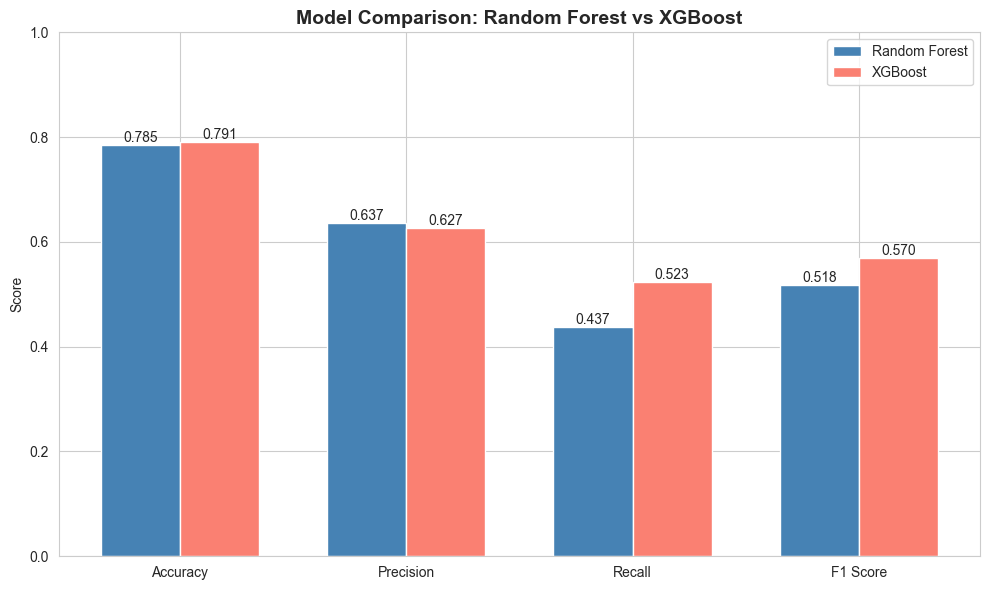

Chart saved


In [7]:
# ============================================
# VISUAL COMPARISON OF BOTH MODELS
# ============================================

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
rf_scores = [rf_accuracy, rf_precision, rf_recall, rf_f1]
xgb_scores = [xgb_accuracy, xgb_precision, xgb_recall, xgb_f1]

x = range(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar([i - width/2 for i in x], rf_scores, 
               width, label='Random Forest', color='steelblue')
bars2 = ax.bar([i + width/2 for i in x], xgb_scores, 
               width, label='XGBoost', color='salmon')

ax.set_title('Model Comparison: Random Forest vs XGBoost', 
             fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.set_xticks(list(x))
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1)
ax.legend()

# Add score labels on top of each bar
for bar in bars1:
    ax.annotate(f'{bar.get_height():.3f}',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha='center', va='bottom', fontsize=10)
for bar in bars2:
    ax.annotate(f'{bar.get_height():.3f}',
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('../reports/model_comparison.png', dpi=150)
plt.show()
print("Chart saved")

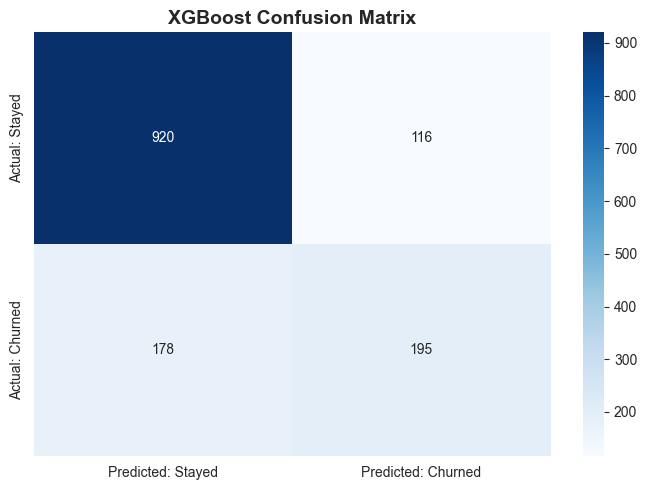

True Negatives  (correctly predicted stayed):  920
False Positives (wrongly predicted churned):   116
False Negatives (missed actual churners):      178
True Positives  (correctly predicted churned): 195


In [8]:
# ============================================
# CONFUSION MATRIX
# Shows exactly where the model gets it right
# and where it makes mistakes
# ============================================

cm = confusion_matrix(y_test, xgb_predictions)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: Stayed', 'Predicted: Churned'],
            yticklabels=['Actual: Stayed', 'Actual: Churned'])

ax.set_title('XGBoost Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/confusion_matrix.png', dpi=150)
plt.show()

# Print what the numbers mean
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (correctly predicted stayed):  {tn}")
print(f"False Positives (wrongly predicted churned):   {fp}")
print(f"False Negatives (missed actual churners):      {fn}")
print(f"True Positives  (correctly predicted churned): {tp}")

In [9]:
summary = """
SUMMARY — Machine Learning Results
=========================================

DATASET SPLIT:
- Training set: 5,634 customers (80%)
- Test set:     1,409 customers (20%)
- Churn rate consistent across both splits 

MODEL RESULTS:
                  Random Forest    XGBoost
  Accuracy:           78.5%         79.1%
  Precision:          63.7%         62.7%
  Recall:             43.7%         52.3%
  F1 Score:           51.8%         57.0%

WINNER: XGBoost — better Recall and F1 Score

CONFUSION MATRIX (XGBoost on 1,409 test customers):
- Correctly predicted stayed:  920 customers
- Correctly predicted churned: 195 customers  
- Missed actual churners:      178 customers
- False alarms:                116 customers

KEY INSIGHT:
The model correctly identified 195 out of 373 churners
(52.3% recall). In a real business, flagging these 195
customers for retention outreach before they leave
represents significant saved revenue.

"""
print(summary)


SUMMARY — Machine Learning Results

DATASET SPLIT:
- Training set: 5,634 customers (80%)
- Test set:     1,409 customers (20%)
- Churn rate consistent across both splits 

MODEL RESULTS:
                  Random Forest    XGBoost
  Accuracy:           78.5%         79.1%
  Precision:          63.7%         62.7%
  Recall:             43.7%         52.3%
  F1 Score:           51.8%         57.0%

WINNER: XGBoost — better Recall and F1 Score

CONFUSION MATRIX (XGBoost on 1,409 test customers):
- Correctly predicted stayed:  920 customers
- Correctly predicted churned: 195 customers  
- Missed actual churners:      178 customers
- False alarms:                116 customers

KEY INSIGHT:
The model correctly identified 195 out of 373 churners
(52.3% recall). In a real business, flagging these 195
customers for retention outreach before they leave
represents significant saved revenue.




In [ ]:
# ============================================
# OVERFITTING / UNDERFITTING CHECK
# Compare training performance vs test performance
# ============================================

# Get predictions on TRAINING data
rf_train_preds = rf_model.predict(X_train)
xgb_train_preds = xgb_model.predict(X_train)

# Random Forest
rf_train_acc = accuracy_score(y_train, rf_train_preds)
rf_test_acc = accuracy_score(y_test, rf_predictions)

# XGBoost
xgb_train_acc = accuracy_score(y_train, xgb_train_preds)
xgb_test_acc = accuracy_score(y_test, xgb_predictions)

print("=" * 45)
print(f"{'Model':<20} {'Train Acc':>10} {'Test Acc':>10} {'Gap':>8}")
print("=" * 45)
print(f"{'Random Forest':<20} {rf_train_acc:>10.3f} {rf_test_acc:>10.3f} {rf_train_acc - rf_test_acc:>8.3f}")
print(f"{'XGBoost':<20} {xgb_train_acc:>10.3f} {xgb_test_acc:>10.3f} {xgb_train_acc - xgb_test_acc:>8.3f}")
print("=" * 45)